Isolation Forest

In [ ]:
# 1. Import Libraries
import pandas as pd

# 2. Load Dataset
file_path = "../datasets/data(2).csv"
df = pd.read_csv(file_path)
df.head()

,node_id,proto_mean,seq_mean,stddev_mean,N_IN_Conn_P_SrcIP_mean,min_mean,state_number_mean,mean_mean,N_IN_Conn_P_DstIP_mean,drate_mean,srate_mean,max_mean,attack
0,192.168.100.1->192.168.100.147,0,4521.000000,0.0,6.000000,0.000055,2,0.000055,1,0.0,0.0,0.000055,0
1,192.168.100.1->192.168.100.148,0,4280.000000,0.0,6.000000,0.000058,2,0.000058,1,0.0,0.0,0.000058,0
2,192.168.100.1->192.168.100.149,0,5412.000000,0.0,6.000000,0.000111,2,0.000111,1,0.0,0.0,0.000111,0
3,192.168.100.1->192.168.100.150,0,4287.000000,0.0,6.000000,0.000065,2,0.000065,1,0.0,0.0,0.000065,0
4,192.168.100.1->192.168.100.27,0,5897.666667,0.0,2.333333,0.000371333333333333,2,0.000371333333333333,1,0.0,0.0,0.000371,0


3. Initial Dataset Inspection

In [43]:
df.shape

(156, 13)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   node_id                 156 non-null    str    
 1   proto_mean              156 non-null    str    
 2   seq_mean                156 non-null    float64
 3   stddev_mean             156 non-null    float64
 4   N_IN_Conn_P_SrcIP_mean  156 non-null    float64
 5   min_mean                156 non-null    str    
 6   state_number_mean       152 non-null    str    
 7   mean_mean               156 non-null    str    
 8   N_IN_Conn_P_DstIP_mean  155 non-null    str    
 9   drate_mean              155 non-null    float64
 10  srate_mean              156 non-null    float64
 11  max_mean                156 non-null    float64
 12  attack                  156 non-null    int64  
dtypes: float64(6), int64(1), str(6)
memory usage: 16.0 KB


In [45]:
df.describe(include="all")

,node_id,proto_mean,seq_mean,stddev_mean,N_IN_Conn_P_SrcIP_mean,min_mean,state_number_mean,mean_mean,N_IN_Conn_P_DstIP_mean,drate_mean,srate_mean,max_mean,attack
count,156,156,156.000000,156.000000,156.000000,156,152,156,155,155.000000,156.000000,156.000000,156.000000
unique,156,37,NaN,NaN,NaN,135,36,136,68,NaN,NaN,NaN,NaN
top,192.168.100.1->192.168.100.147,4,NaN,NaN,NaN,0,2,0,1,NaN,NaN,NaN,NaN
freq,1,84,NaN,NaN,NaN,21,82,20,30,NaN,NaN,NaN,NaN
mean,NaN,NaN,13502.508967,0.077311,31.646303,NaN,NaN,NaN,NaN,5.543260,1224.661194,0.570979,0.205128
std,NaN,NaN,24859.387459,0.229249,28.279033,NaN,NaN,NaN,NaN,18.650598,7907.155971,1.187631,0.405096
min,NaN,NaN,1.666667,0.000000,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,3782.625000,0.000000,6.812500,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000244,0.000000
50%,NaN,NaN,5439.750000,0.000000,20.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.081846,0.000000
75%,NaN,NaN,13818.694115,0.000053,57.000000,NaN,NaN,NaN,NaN,0.057148,0.379917,0.323650,0.000000


In [46]:
df.isna().sum()

node_id                   0
proto_mean                0
seq_mean                  0
stddev_mean               0
N_IN_Conn_P_SrcIP_mean    0
min_mean                  0
state_number_mean         4
mean_mean                 0
N_IN_Conn_P_DstIP_mean    1
drate_mean                1
srate_mean                0
max_mean                  0
attack                    0
dtype: int64

In [ ]:
# 4. Separate Actual Label
y = df["attack"]

In [ ]:
# 5. Remove Non-Feature Columns
X = df.drop(columns=["attack", "node_id"])
X.head()

,proto_mean,seq_mean,stddev_mean,N_IN_Conn_P_SrcIP_mean,min_mean,state_number_mean,mean_mean,N_IN_Conn_P_DstIP_mean,drate_mean,srate_mean,max_mean
0,0,4521.000000,0.0,6.000000,0.000055,2,0.000055,1,0.0,0.0,0.000055
1,0,4280.000000,0.0,6.000000,0.000058,2,0.000058,1,0.0,0.0,0.000058
2,0,5412.000000,0.0,6.000000,0.000111,2,0.000111,1,0.0,0.0,0.000111
3,0,4287.000000,0.0,6.000000,0.000065,2,0.000065,1,0.0,0.0,0.000065
4,0,5897.666667,0.0,2.333333,0.000371333333333333,2,0.000371333333333333,1,0.0,0.0,0.000371


In [ ]:
# 6. Convert Features to Numeric
X = X.apply(pd.to_numeric, errors="coerce")

# 7. Check Missing Values After Conversion
X.isna().sum()

proto_mean                3
seq_mean                  0
stddev_mean               0
N_IN_Conn_P_SrcIP_mean    0
min_mean                  1
state_number_mean         5
mean_mean                 2
N_IN_Conn_P_DstIP_mean    5
drate_mean                1
srate_mean                0
max_mean                  0
dtype: int64

In [ ]:
# 8. Fill Missing Values
X = X.fillna(X.median())

In [ ]:
# 9. Verify Final Data
df.isnull().sum()

node_id                   0
proto_mean                0
seq_mean                  0
stddev_mean               0
N_IN_Conn_P_SrcIP_mean    0
min_mean                  0
state_number_mean         4
mean_mean                 0
N_IN_Conn_P_DstIP_mean    1
drate_mean                1
srate_mean                0
max_mean                  0
attack                    0
dtype: int64

In [57]:
print(X.dtypes)

proto_mean                float64
seq_mean                  float64
stddev_mean               float64
N_IN_Conn_P_SrcIP_mean    float64
min_mean                  float64
state_number_mean         float64
mean_mean                 float64
N_IN_Conn_P_DstIP_mean    float64
drate_mean                float64
srate_mean                float64
max_mean                  float64
dtype: object


In [ ]:
# 10. Create Isolation Forest
from sklearn.ensemble import IsolationForest

isolation_forest=IsolationForest(n_estimators=100,contamination="auto",random_state=42)

# 11. Train Isolation Forest
isolation_forest.fit(X)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [ ]:
# 12. Predict Anomalies
predictions = isolation_forest.predict(X)

# 13. Store Isolation Forest Prediction
df["isolation_prediction"] = predictions

In [ ]:
# 14. Convert Prediction to Attack Format
df["predicted_attack"] = df["isolation_prediction"].map({1: 0,-1: 1})

In [ ]:
# 15. Display Results
print(
    df[
        [
            "attack",
            "isolation_prediction",
            "predicted_attack"
        ]
    ].head(20)
)

    attack  isolation_prediction  predicted_attack
0        0                     1                 0
1        0                     1                 0
2        0                     1                 0
3        0                     1                 0
4        0                     1                 0
5        0                     1                 0
6        0                     1                 0
7        0                     1                 0
8        0                     1                 0
9        0                     1                 0
10       1                    -1                 1
11       1                     1                 0
12       1                    -1                 1
13       1                    -1                 1
14       0                     1                 0
15       0                     1                 0
16       0                     1                 0
17       0                    -1                 1
18       0                     

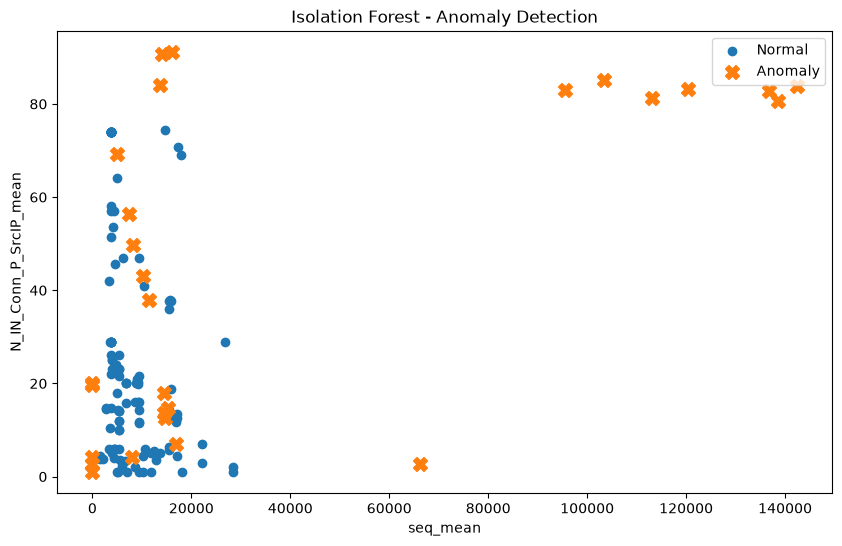

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Normal observations
normal = df["predicted_attack"] == 0

# Anomalies
anomaly = df["predicted_attack"] == 1

plt.scatter(
    df.loc[normal, "seq_mean"],
    df.loc[normal, "N_IN_Conn_P_SrcIP_mean"],
    label="Normal"
)

plt.scatter(
    df.loc[anomaly, "seq_mean"],
    df.loc[anomaly, "N_IN_Conn_P_SrcIP_mean"],
    label="Anomaly",
    marker="X",
    s=100
)

plt.xlabel("seq_mean")
plt.ylabel("N_IN_Conn_P_SrcIP_mean")
plt.title("Isolation Forest - Anomaly Detection")
plt.legend()
plt.show()